# 损失与策略指标

| 指标名                   | 含义                        |
| :-------------------- | :------------------------ |
| `actor/loss`          | PPO/GRPO 策略损失             |
| `actor/loss_policy`   | 策略梯度损失（clip 项）            |
| `actor/loss_value`    | 价值函数损失                    |
| `actor/ppo_kl`        | 当前策略与参考模型的 KL 散度          |
| `actor/entropy`       | 策略熵（生成分布的随机性）             |
| `actor/ratio`         | 重要性采样比率 $\rho$ 的均值/最大/最小值 |
| `actor/clip_fraction` | 被 clip 的样本比例              |

## 诊断价值：
- entropy 持续下降 → 模式崩溃前兆
- ppo_kl 飙升 → 策略偏离参考模型太远
- clip_fraction 过高（>50%）→ 学习率可能过大



# 七大核心指标详解
##  actor/loss —— 总策略损失
### 组成：PPO 总损失 = 策略损失 + 价值损失 + 熵奖励 + KL 惩罚

$L_{total}=L^{policy}+c_1L^{value}−c_2H+β⋅D_{KL}$ 

### 代码实现：

In [ ]:
def compute_total_loss(policy_loss, value_loss, entropy, kl_div,
                       value_coef=0.5, entropy_coef=0.01, kl_coef=0.01):
    return policy_loss + value_coef * value_loss - entropy_coef * entropy + kl_coef * kl_div

#### 诊断：
- 总损失突然 NaN/Inf → 检查 ratio 是否爆炸、reward 是否异常。

## actor/loss_policy —— PPO-Clip 策略损失
### 核心公式：
$L^{policy}=−E[min(ρ_t \hat{A_t},,clip(ρ_t,,1−ϵ,1+ϵ)\hat{A_t})]$

其中$ρ_t = \frac{π_θ(a_t|s_t)}{π_θold(a_t|s_t)}$

### 代码实现

In [ ]:
def compute_policy_loss(new_log_probs, old_log_probs, advantages, epsilon=0.2):
    """
    Args:
        new_log_probs: [B, T] 新策略的对数概率
        old_log_probs: [B, T] 旧策略的对数概率
        advantages: [B, T] 优势值
    """
    # 重要性采样比率
    log_ratio = new_log_probs - old_log_probs
    ratio = torch.exp(log_ratio)
    
    # 未裁剪的目标
    surr1 = ratio * advantages
    
    # 裁剪后的目标
    clipped_ratio = torch.clamp(ratio, 1 - epsilon, 1 + epsilon)
    surr2 = clipped_ratio * advantages
    
    # 取最小（悲观估计）
    policy_loss = -torch.min(surr1, surr2).mean()
    
    return policy_loss, ratio

## actor/loss_value —— 价值函数损失
### 公式：
$L^{value}=E[(V_ϕ(s_t) −R^{GAE}_t)^2]$

### 代码实现：

In [ ]:
def compute_value_loss(values, returns):
    """
    Args:
        values: [B, T] Critic 预测的价值
        returns: [B, T] GAE 计算的回报
    """
    return F.mse_loss(values, returns)

#### 诊断：
- value_loss 持续很高 → Critic 拟合困难，可能需要更多 Critic 更新步数或调整 GAE 参数。

## actor/ppo_kl —— 策略与参考模型的 KL 散度
公式（近似 KL）：

In [1]:
from IPython.display import Image

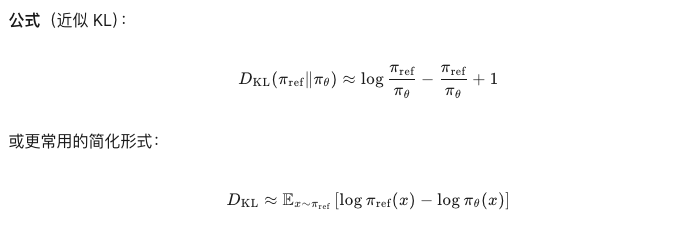

In [2]:
Image(filename='./Image/kl.png')

### 代码实现：

In [ ]:
def compute_kl_divergence(ref_log_probs, new_log_probs, mask):
    """
    Args:
        ref_log_probs: [B, T] 参考模型（SFT）的对数概率
        new_log_probs: [B, T] 当前策略的对数概率
        mask: [B, T] 有效 token 掩码
    """
    kl = (ref_log_probs - new_log_probs) * mask
    # 按有效 token 平均
    return kl.sum() / mask.sum()

### 诊断阈值：

|     KL 范围    | 状态                    |
| :----------: | :-------------------- |
|   `< 0.01`   | 策略几乎未偏离参考模型，探索不足      |
| `0.01 ~ 0.1` | ✅ 健康区间                |
|    `> 0.5`   | 🚨 偏离过远，可能出现奖励黑客或模式崩溃 |


## actor/entropy —— 策略熵
公式：

$H(π)=−a∑π(a∣s)logπ(a∣s)$

### 代码实现：

In [ ]:
def compute_entropy(logits, mask):
    """
    Args:
        logits: [B, T, V] 未归一化的分数
        mask: [B, T]
    """
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    entropy = -(probs * log_probs).sum(dim=-1)  # [B, T]
    
    # 按有效位置平均
    entropy = (entropy * mask).sum() / mask.sum()
    return entropy

### 诊断：

In [ ]:
| 熵值趋势 | 含义                        |
| :--- | :------------------------ |
| 持续下降 | 模型越来越"确定"，探索减少，**模式崩溃前兆** |
| 突然骤降 | 可能某个 token 的概率被推到接近 1     |
| 接近 0 | 模型几乎总是输出固定 token，完全丧失多样性  |
| 过高   | 模型过于随机，没有学到有效策略           |


## actor/ratio —— 重要性采样比率 ρ
公式：

$ρ_t = \frac{π_θ(a_t|s_t)}{π_θold(a_t|s_t)} = exp(logπ_θ - logπ_{old})$

### 监控维度：

In [ ]:
ratio_stats = {
    'ratio_mean': ratio.mean().item(),
    'ratio_max': ratio.max().item(),
    'ratio_min': ratio.min().item(),
    'ratio_std': ratio.std().item(),
}

### 诊断：

| ratio 状态        | 含义                  |
| :-------------- | :------------------ |
| `mean ≈ 1.0`    | 策略更新幅度适中            |
| `max > 10`      | 某些 token 概率剧变，数值不稳定 |
| `min < 0.1`     | 某些 token 概率被大幅压低    |
| `mean` 持续偏离 1.0 | 学习率可能过大，策略更新过于激进    |


## actor/clip_fraction —— 被裁剪样本比例
### 计算：

$clip_fraction= \frac{1}{N} \sum_{i}{1[∣ρ_i−1∣>ϵ]}$

即 ratio 落在 (1−ϵ,1+ϵ)  之外的样本比例。

### 代码实现：

In [ ]:
def compute_clip_fraction(ratio, epsilon=0.2):
    clipped = (ratio < (1 - epsilon)) | (ratio > (1 + epsilon))
    return clipped.float().mean().item()

### 诊断：

| clip\_fraction | 诊断                            |
| :------------: | :---------------------------- |
|     `< 10%`    | 更新保守，可能学习率过低                  |
|   `10% ~ 30%`  | ✅ 健康区间                        |
|     `> 50%`    | 🚨 过于激进！大量样本被裁剪，有效梯度丢失，应降低学习率 |


## 完整训练监控类

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from collections import defaultdict

class PolicyLossMonitor:
    """
    verl 风格的损失与策略指标监控器
    """
    def __init__(self, epsilon=0.2, kl_coef=0.01, entropy_coef=0.01, value_coef=0.5):
        self.epsilon = epsilon
        self.kl_coef = kl_coef
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        self.history = defaultdict(list)
    
    def compute_all_metrics(self, new_log_probs, old_log_probs, ref_log_probs,
                           advantages, values, returns, logits, mask):
        """
        计算所有策略指标
        
        Args:
            new_log_probs: [B, T] 当前策略 log prob
            old_log_probs: [B, T] 旧策略 log prob
            ref_log_probs: [B, T] 参考模型 log prob
            advantages: [B, T] 优势值
            values: [B, T] Critic 预测
            returns: [B, T] GAE 回报
            logits: [B, T, V] 策略 logits
            mask: [B, T] 有效 token 掩码
        """
        metrics = {}
        
        # 1. 计算 ratio
        log_ratio = new_log_probs - old_log_probs
        ratio = torch.exp(log_ratio)
        
        # 2. Policy Loss (PPO-Clip)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - self.epsilon, 1 + self.epsilon) * advantages
        policy_loss = -torch.min(surr1, surr2)
        policy_loss = (policy_loss * mask).sum() / mask.sum()
        
        # 3. Value Loss
        value_loss = F.mse_loss(values, returns, reduction='none')
        value_loss = (value_loss * mask).sum() / mask.sum()
        
        # 4. Entropy
        probs = F.softmax(logits, dim=-1)
        log_probs_all = F.log_softmax(logits, dim=-1)
        entropy = -(probs * log_probs_all).sum(dim=-1)
        entropy = (entropy * mask).sum() / mask.sum()
        
        # 5. KL Divergence (参考模型 vs 当前策略)
        kl = (ref_log_probs - new_log_probs) * mask
        kl_div = kl.sum() / mask.sum()
        
        # 6. Total Loss
        total_loss = (policy_loss 
                      + self.value_coef * value_loss 
                      - self.entropy_coef * entropy 
                      + self.kl_coef * kl_div)
        
        # 7. Ratio Stats
        ratio_masked = ratio[mask.bool()]
        metrics['ratio_mean'] = ratio_masked.mean().item()
        metrics['ratio_max'] = ratio_masked.max().item()
        metrics['ratio_min'] = ratio_masked.min().item()
        
        # 8. Clip Fraction
        clipped = (ratio < (1 - self.epsilon)) | (ratio > (1 + self.epsilon))
        clip_frac = (clipped.float() * mask).sum() / mask.sum()
        metrics['clip_fraction'] = clip_frac.item()
        
        # 9. 组装损失指标
        metrics['loss_total'] = total_loss.item()
        metrics['loss_policy'] = policy_loss.item()
        metrics['loss_value'] = value_loss.item()
        metrics['entropy'] = entropy.item()
        metrics['ppo_kl'] = kl_div.item()
        
        # 记录历史
        for k, v in metrics.items():
            self.history[k].append(v)
        
        return total_loss, metrics
    
    def diagnose(self, step):
        """打印诊断信息"""
        h = self.history
        
        print(f"\n{'='*70}")
        print(f"Step {step} 策略指标诊断")
        print(f"{'='*70}")
        
        # 损失
        print(f"【损失】Total: {h['loss_total'][-1]:.4f} | "
              f"Policy: {h['loss_policy'][-1]:.4f} | "
              f"Value: {h['loss_value'][-1]:.4f}")
        
        # KL
        kl = h['ppo_kl'][-1]
        status = "✅" if 0.01 <= kl <= 0.1 else "⚠️" if kl < 0.5 else "🚨"
        print(f"【KL 散度】{kl:.4f} {status}")
        if kl > 0.5:
            print(f"   🚨 警告：策略偏离参考模型过远！")
        
        # 熵
        ent = h['entropy'][-1]
        status = "✅" if ent > 0.5 else "⚠️"
        print(f"【策略熵】{ent:.4f} {status}")
        if ent < 0.3:
            print(f"   ⚠️ 警告：熵过低，可能出现模式崩溃！")
        
        # Ratio
        print(f"【Ratio】mean={h['ratio_mean'][-1]:.3f}, "
              f"max={h['ratio_max'][-1]:.3f}, "
              f"min={h['ratio_min'][-1]:.3f}")
        if h['ratio_max'][-1] > 10:
            print(f"   🚨 警告：存在极端 ratio，数值不稳定！")
        
        # Clip Fraction
        cf = h['clip_fraction'][-1]
        status = "✅" if 0.1 <= cf <= 0.3 else "⚠️" if cf < 0.5 else "🚨"
        print(f"【Clip Fraction】{cf*100:.1f}% {status}")
        if cf > 0.5:
            print(f"   🚨 警告：超过 50% 样本被裁剪，学习率可能过大！")
        
        print(f"{'='*70}")


# ==================== 使用示例 ====================

# 模拟数据
B, T, V = 4, 20, 1000
new_log_probs = torch.randn(B, T)
old_log_probs = torch.randn(B, T)
ref_log_probs = torch.randn(B, T)
advantages = torch.randn(B, T)
values = torch.randn(B, T)
returns = torch.randn(B, T)
logits = torch.randn(B, T, V)
mask = torch.ones(B, T)

monitor = PolicyLossMonitor(epsilon=0.2)

# 模拟训练循环
for step in range(20):
    # 模拟训练动态变化
    if step > 10:
        # 模拟模式崩溃：熵骤降
        logits = logits * 10  # 使分布更尖锐
    if step > 15:
        # 模拟 KL 爆炸
        new_log_probs = ref_log_probs + torch.randn(B, T) * 2
    
    total_loss, metrics = monitor.compute_all_metrics(
        new_log_probs, old_log_probs, ref_log_probs,
        advantages, values, returns, logits, mask
    )
    
    # 反向传播（仅演示）
    total_loss.backward()
    
    if step % 5 == 0:
        monitor.diagnose(step)

print("\n训练结束，历史摘要：")
print(f"  平均 Policy Loss: {np.mean(monitor.history['loss_policy']):.4f}")
print(f"  平均 KL: {np.mean(monitor.history['ppo_kl']):.4f}")
print(f"  平均 Entropy: {np.mean(monitor.history['entropy']):.4f}")
print(f"  平均 Clip Fraction: {np.mean(monitor.history['clip_fraction'])*100:.1f}%")

## 诊断速查表

| 指标              | 健康范围        | 危险信号       | 修复建议                  |
| :-------------- | :---------- | :--------- | :-------------------- |
| `loss_policy`   | 稳定下降或波动     | 突然 NaN/Inf | 检查 ratio、降低学习率        |
| `loss_value`    | 稳定下降        | 持续高位       | 增加 Critic 更新步数        |
| `ppo_kl`        | 0.01 ~ 0.1  | > 0.5      | 增大 KL 系数、降低学习率        |
| `entropy`       | > 0.5（归一化后） | < 0.3      | 增大 entropy bonus、提高温度 |
| `ratio_max`     | < 5         | > 10       | 检查旧策略概率是否接近 0         |
| `clip_fraction` | 10% ~ 30%   | > 50%      | 降低学习率、减小 epsilon      |


## 一句话总结
- 这七个指标构成了 RL 训练的"仪表盘"：Policy Loss 看学习是否有效，Value Loss 看 Critic 是否靠谱，KL 看有没有跑偏，Entropy 看还有没有探索，Ratio 看数值是否稳定，Clip Fraction 看更新是否激进。任何一个亮红灯，都意味着训练需要立即干预。